In [ ]:
# ==========================================
# 1. Setup (Mount Drive + Paths)
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CrowdCounting/Crowd_density_estimation-main

import sys
sys.path.append('/content/drive/MyDrive/CrowdCounting/Crowd_density_estimation-main/src')

import torch
print("CUDA Available:", torch.cuda.is_available())

Mounted at /content/drive
/content/drive/MyDrive/CrowdCounting/Crowd_density_estimation-main
CUDA Available: False


In [ ]:
# ==========================================
# 2. Imports
# ==========================================

import os
import numpy as np
import scipy.io
from PIL import Image
import torch
from torch.utils.data import DataLoader

from dataset import ShanghaiTechDataset
from cnn import SimpleCNN

In [ ]:
# ==========================================
# 3. Part B Dataset Paths
# ==========================================

train_img_dir = "/content/drive/MyDrive/CrowdCounting/dataset/ShanghaiTech/part_B/train_data/images"
train_gt_dir  = "/content/drive/MyDrive/CrowdCounting/dataset/ShanghaiTech/part_B/train_data/ground-truth"

test_img_dir = "/content/drive/MyDrive/CrowdCounting/dataset/ShanghaiTech/part_B/test_data/images"
test_gt_dir  = "/content/drive/MyDrive/CrowdCounting/dataset/ShanghaiTech/part_B/test_data/ground-truth"

print("Train images:", len(os.listdir(train_img_dir)))
print("Test images:", len(os.listdir(test_img_dir)))

Train images: 400
Test images: 316


In [ ]:
# ==========================================
# 4. DataLoader
# ==========================================

train_dataset = ShanghaiTechDataset(train_img_dir, train_gt_dir, resize=(256,256))
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("Training samples:", len(train_dataset))

Training samples: 400


In [ ]:
# ==========================================
# 5. Model Setup
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model ready on:", device)

Model ready on: cuda


In [ ]:
# ==========================================
# 6. Training
# ==========================================

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, densities in train_loader:
        imgs = imgs.to(device)
        densities = densities.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, densities)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {total_loss/len(train_loader):.6f}")

Epoch [1/20] - Loss: 0.000266
Epoch [2/20] - Loss: 0.000146
Epoch [3/20] - Loss: 0.000143
Epoch [4/20] - Loss: 0.000141
Epoch [5/20] - Loss: 0.000140
Epoch [6/20] - Loss: 0.000139
Epoch [7/20] - Loss: 0.000139
Epoch [8/20] - Loss: 0.000138
Epoch [9/20] - Loss: 0.000138
Epoch [10/20] - Loss: 0.000137
Epoch [11/20] - Loss: 0.000137
Epoch [12/20] - Loss: 0.000137
Epoch [13/20] - Loss: 0.000137
Epoch [14/20] - Loss: 0.000136
Epoch [15/20] - Loss: 0.000136
Epoch [16/20] - Loss: 0.000135
Epoch [17/20] - Loss: 0.000136
Epoch [18/20] - Loss: 0.000135
Epoch [19/20] - Loss: 0.000135
Epoch [20/20] - Loss: 0.000135


In [ ]:
# ==========================================
# 7. Save Model (Part B CNN 20 epochs)
# ==========================================

torch.save(model.state_dict(),
           "/content/drive/MyDrive/CrowdCounting/partB_cnn_20epochs.pth")

print("Part B CNN model saved successfully.")

Part B CNN model saved successfully.


In [ ]:
# ==========================================
# 8. Evaluate on Part B Test Set
# ==========================================

model.eval()

mae = 0
num_images = 0

with torch.no_grad():
    for img_name in sorted(os.listdir(test_img_dir)):

        # Load image
        img_path = os.path.join(test_img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0

        img = np.array(
            Image.fromarray((img * 255).astype(np.uint8))
            .resize((256, 256), Image.BILINEAR)
        ).astype(np.float32) / 255.0

        img = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).to(device)

        # Predict
        output = model(img)
        pred_count = output.sum().item()

        # Ground truth
        mat_name = "GT_" + img_name.replace(".jpg", ".mat")
        mat_path = os.path.join(test_gt_dir, mat_name)

        mat = scipy.io.loadmat(mat_path)
        gt_points = mat["image_info"][0][0][0][0][0]
        gt_count = gt_points.shape[0]

        mae += abs(pred_count - gt_count)
        num_images += 1

mae = mae / num_images
print("Part B Test MAE:", mae)

Part B Test MAE: 58.64562824104406


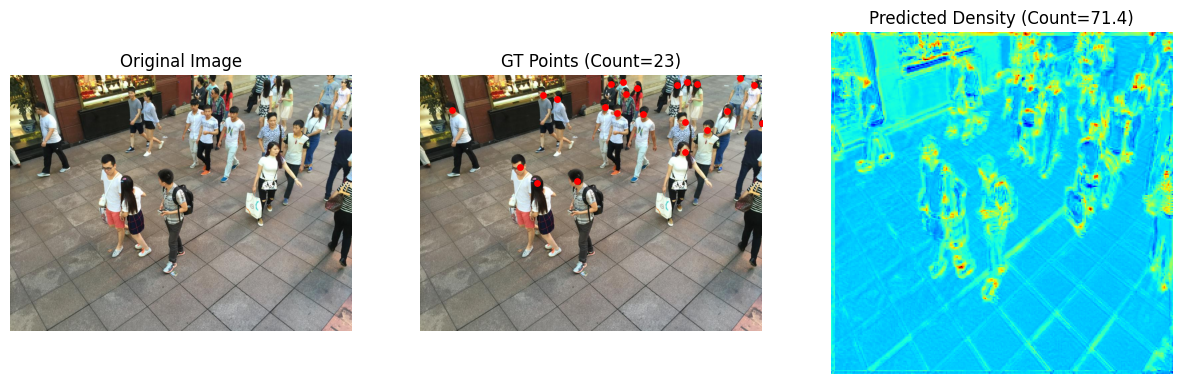

In [ ]:
# ==========================================
# 9. Visualize Prediction vs Ground Truth
# ==========================================

import matplotlib.pyplot as plt
import scipy.io

model.eval()

sample_img = sorted(os.listdir(test_img_dir))[0]

# ----- Load image -----
img_path = os.path.join(test_img_dir, sample_img)
img = Image.open(img_path).convert("RGB")
img_np = np.array(img)

img_resized = np.array(
    Image.fromarray(img_np)
    .resize((256,256), Image.BILINEAR)
).astype(np.float32) / 255.0

input_tensor = torch.from_numpy(img_resized).permute(2,0,1).unsqueeze(0).to(device)

# ----- Predict -----
with torch.no_grad():
    output = model(input_tensor)

pred_density = output.squeeze().cpu().numpy()
pred_count = pred_density.sum()

# ----- Load Ground Truth (.mat) -----
mat_name = "GT_" + sample_img.replace(".jpg", ".mat")
mat_path = os.path.join(test_gt_dir, mat_name)

mat = scipy.io.loadmat(mat_path)
gt_points = mat["image_info"][0][0][0][0][0]
gt_count = gt_points.shape[0]

# ----- Plot -----
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

# Ground Truth Points
plt.subplot(1,3,2)
plt.imshow(img_np)
plt.scatter(gt_points[:,0], gt_points[:,1], s=15, c='red')
plt.title(f"GT Points (Count={gt_count})")
plt.axis("off")

# Predicted Density
plt.subplot(1,3,3)
plt.imshow(pred_density, cmap='jet')
plt.title(f"Predicted Density (Count={pred_count:.1f})")
plt.axis("off")

plt.show()